# Random Forest

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/random_forest.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Math Intuition](#2-math-intuition)
   - 2.1 The Problem with a Single Tree
   - 2.2 Bagging — Bootstrap Aggregation
   - 2.3 The Random Subspace Method
   - 2.4 Why Randomness Reduces Variance
   - 2.5 Aggregation — Voting and Averaging
   - 2.6 Out-of-Bag (OOB) Error
   - 2.7 Feature Importance
3. [Visual Intuition](#3-visual-intuition)
4. [Code from Scratch](#4-code-from-scratch)
5. [Sklearn Implementation](#5-sklearn-implementation)
6. [Hyperparameter Tuning](#6-hyperparameter-tuning)
7. [Common Mistakes](#7-common-mistakes)
8. [Exercises](#8-exercises)


## 1. Concept Overview

Random Forest is an **ensemble** of decision trees. Each tree is trained on a random bootstrap sample of the data, and each split considers only a random subset of features. Predictions are made by **majority vote** (classification) or **averaging** (regression).

**The core idea:** A single decision tree overfits easily and is unstable. If you average many trees that each overfit in **different, uncorrelated ways**, the errors cancel out and the ensemble generalizes well.

**When to use it:**
- Strong general-purpose baseline for tabular data
- When you want good accuracy with minimal tuning
- When you want built-in feature importance and OOB error estimation

**Strengths:** Robust to overfitting, no feature scaling needed, parallelizable, built-in OOB validation

**Weaknesses:** Less interpretable than a single tree, slower inference, struggles with very high-dimensional sparse data


## 2. Math Intuition

### 2.1 The Problem with a Single Tree

The expected test error decomposes as:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

A deep decision tree has **low bias** but **high variance** — it memorizes the training set but fails to generalize. Random Forest fixes the variance problem while keeping the low bias.

---

### 2.2 Bagging — Bootstrap Aggregation

**Bootstrap sampling:** Given dataset $D$ with $m$ samples, create $D_b$ by sampling $m$ samples **with replacement**. Each bootstrap sample contains ~63.2% of the original samples.

Why 63.2%? Probability a specific sample is NOT selected in $m$ draws:

$$P(\text{not selected}) = \left(1 - \frac{1}{m}\right)^m \xrightarrow{m \to \infty} e^{-1} \approx 0.368$$

So ~36.8% of samples are left out — these are the **Out-of-Bag (OOB)** samples.

Train $B$ trees, each on its own bootstrap sample. Aggregate:

$$\hat{y}_{\text{classification}} = \text{mode}\left(h_1(x), \dots, h_B(x)\right)$$
$$\hat{y}_{\text{regression}} = \frac{1}{B} \sum_{b=1}^{B} h_b(x)$$

---

### 2.3 The Random Subspace Method (Feature Randomness)

Bagging alone produces **correlated trees** — if one strong feature exists, most trees use it at the root. Random Forest adds a second randomness: **at each split**, only $k$ randomly chosen features are considered.

Standard choices:
- Classification: $k = \lfloor\sqrt{n}\rfloor$
- Regression: $k = \lfloor n/3 \rfloor$

This **decorrelates** the trees, making the ensemble more diverse.

---

### 2.4 Why Randomness Reduces Variance

For $B$ trees each with variance $\sigma^2$ and pairwise correlation $\rho$:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^{B} h_b(x)\right) = \rho \sigma^2 + \frac{1-\rho}{B} \sigma^2$$

As $B \to \infty$, variance floor $\to \rho\sigma^2$.

**Key insight:** Feature randomness reduces $\rho$ (correlation between trees) → lower variance floor. This is why Random Forest beats plain Bagging.

---

### 2.5 Aggregation — Hard vs Soft Voting

**Hard voting:** each tree votes one class label, majority wins.

**Soft voting (probability averaging):** average predicted probabilities, pick highest:

$$P(y=k \mid x) = \frac{1}{B} \sum_{b=1}^{B} P_b(y=k \mid x)$$

Soft voting produces better-calibrated probabilities. Sklearn uses this for `predict_proba()`.

---

### 2.6 Out-of-Bag (OOB) Error

Each tree is trained on ~63.2% of data. For each sample $x_i$, collect predictions only from trees that did **not** see $x_i$ during training:

$$\text{OOB Error} = \frac{1}{m} \sum_{i=1}^{m} \mathbb{1}[\hat{y}_i^{\text{OOB}} \neq y_i]$$

OOB error is a nearly unbiased estimate of test error — **free cross-validation** without a separate validation set.

---

### 2.7 Feature Importance

For each feature $j$, importance = total impurity decrease caused by splits on $j$, averaged across all trees, weighted by sample count:

$$\text{Importance}(j) = \frac{1}{B} \sum_{b=1}^{B} \sum_{\substack{\text{nodes } t \\ \text{split on } j}} \frac{n_t}{m} \Delta I(t)$$

More reliable than single-tree importance because it averages across many trees.


## 3. Visual Intuition

In [19]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


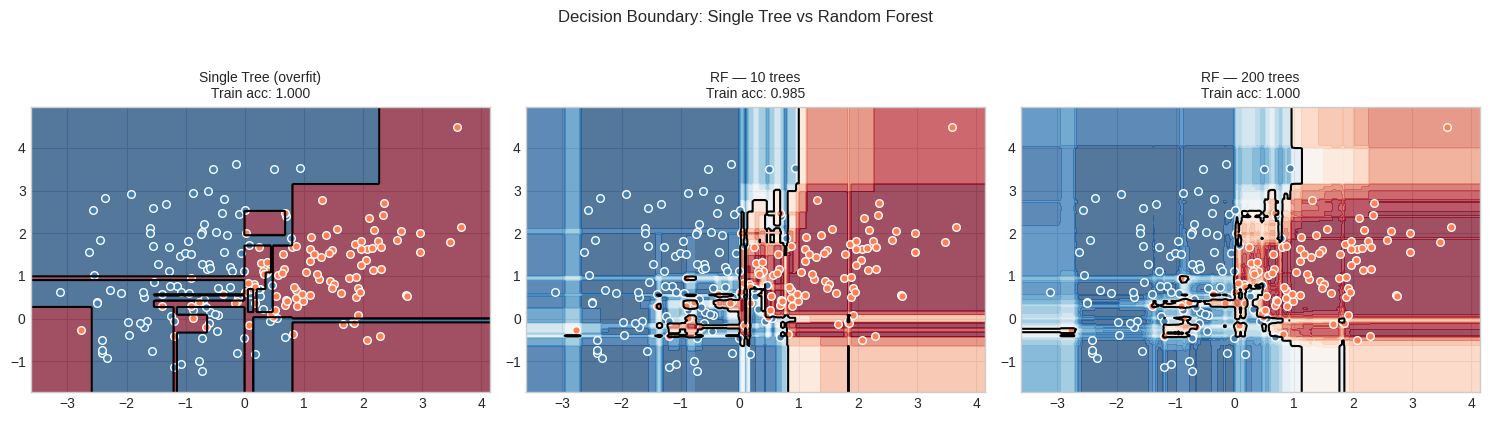

In [20]:
# ── Plot 1: Decision boundary — single tree vs forest ─────────────────────────
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X_v, y_v = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                 n_informative=2, random_state=42, n_clusters_per_class=1)

h = 0.03
x_min, x_max = X_v[:,0].min()-0.5, X_v[:,0].max()+0.5
y_min, y_max = X_v[:,1].min()-0.5, X_v[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [
    (DecisionTreeClassifier(max_depth=None, random_state=42), 'Single Tree (overfit)'),
    (RandomForestClassifier(n_estimators=10,  random_state=42, n_jobs=-1), 'RF — 10 trees'),
    (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1), 'RF — 200 trees'),
]

for ax, (model, title) in zip(axes, models):
    model.fit(X_v, y_v)
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X_v[y_v==0,0], X_v[y_v==0,1], c='steelblue', edgecolors='white', s=30)
    ax.scatter(X_v[y_v==1,0], X_v[y_v==1,1], c='coral',     edgecolors='white', s=30)
    ax.set_title(f"{title}\nTrain acc: {model.score(X_v, y_v):.3f}", fontsize=10)

plt.suptitle("Decision Boundary: Single Tree vs Random Forest", fontsize=12, y=1.04)
plt.tight_layout()
plt.show()


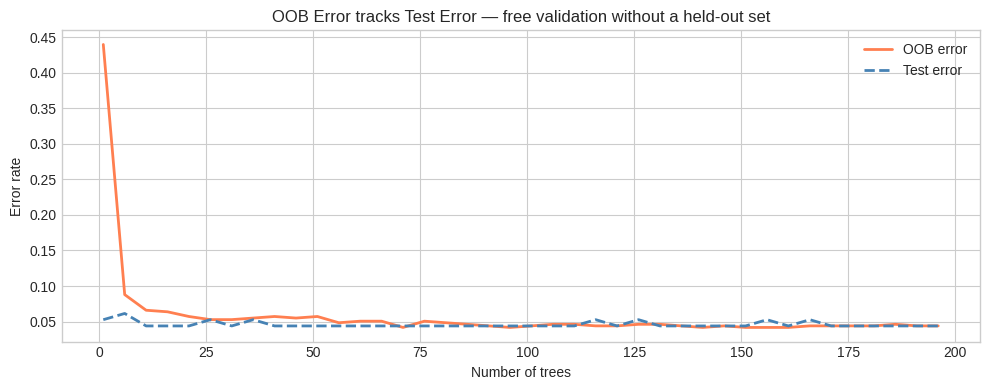

In [21]:
# ── Plot 2: OOB error and test error converge as trees increase ───────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2,
                                            random_state=42, stratify=y_bc)

n_range = range(1, 201, 5)
oob_errs, test_errs = [], []

for n in n_range:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    oob_errs.append(1 - rf.oob_score_)
    test_errs.append(1 - rf.score(X_te, y_te))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(n_range), oob_errs,  color='coral',     linewidth=2, label='OOB error')
ax.plot(list(n_range), test_errs, color='steelblue', linewidth=2,
        linestyle='--', label='Test error')
ax.set_title("OOB Error tracks Test Error — free validation without a held-out set")
ax.set_xlabel("Number of trees")
ax.set_ylabel("Error rate")
ax.legend()
plt.tight_layout()
plt.show()


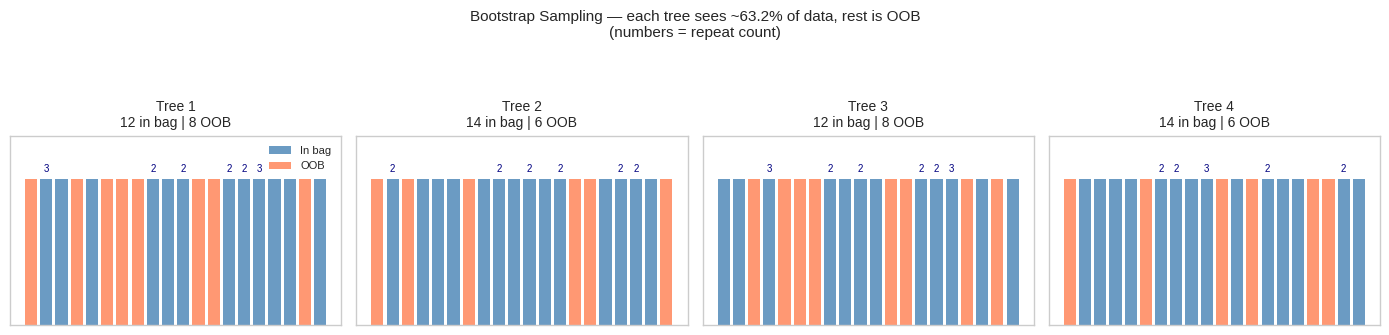

In [22]:
# ── Plot 3: Bootstrap sampling visualization ──────────────────────────────────
m = 20
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for i, ax in enumerate(axes):
    boot_idx = rng.choice(m, size=m, replace=True)
    in_bag   = np.zeros(m, dtype=bool)
    in_bag[np.unique(boot_idx)] = True
    counts   = np.bincount(boot_idx, minlength=m)

    ax.bar(np.where(in_bag)[0],  np.ones(in_bag.sum()),  color='steelblue', alpha=0.8, label='In bag')
    ax.bar(np.where(~in_bag)[0], np.ones((~in_bag).sum()), color='coral',   alpha=0.8, label='OOB')

    for j, c in enumerate(counts):
        if c > 1:
            ax.text(j, 1.05, str(c), ha='center', fontsize=7, color='navy')

    ax.set_title(
        f"Tree {i+1}\n{in_bag.sum()} in bag | {(~in_bag).sum()} OOB",
        fontsize=10
    )
    ax.set_ylim(0, 1.3)
    ax.set_xticks([])
    ax.set_yticks([])
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle(
    "Bootstrap Sampling — each tree sees ~63.2% of data, rest is OOB\n(numbers = repeat count)",
    fontsize=11,
    y=1.1
 )
plt.tight_layout()
plt.show()


## 4. Code from Scratch

In [23]:
# ── Minimal Decision Tree that supports max_features ─────────────────────────
class DTNode:
    def __init__(self):
        self.feature_idx = self.threshold = self.left = self.right = None
        self.is_leaf = False
        self.prediction = None

class RFTree:
    def __init__(self, max_depth=None, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = self.n_classes_ = None

    @staticmethod
    def _entropy(y):
        m = len(y)
        if m == 0: return 0.0
        probs = np.bincount(y)[np.bincount(y) > 0] / m
        return -np.sum(probs * np.log2(probs + 1e-12))

    def _best_split(self, X, y, rng):
        n = X.shape[1]
        k = min(self.max_features or n, n)
        feats = rng.choice(n, size=k, replace=False)
        best_gain, best_feat, best_thr = -1, None, None
        Hp = self._entropy(y)
        m  = len(y)
        for f in feats:
            for t in (np.unique(X[:,f])[:-1] + np.unique(X[:,f])[1:]) / 2:
                lm = X[:,f] <= t
                if lm.sum() == 0 or (~lm).sum() == 0: continue
                g = Hp - (lm.sum()/m)*self._entropy(y[lm]) - ((~lm).sum()/m)*self._entropy(y[~lm])
                if g > best_gain:
                    best_gain, best_feat, best_thr = g, f, t
        return best_feat, best_thr

    def _build(self, X, y, depth, rng):
        node = DTNode()
        if len(np.unique(y))==1 or len(y)<self.min_samples_split or            (self.max_depth and depth>=self.max_depth):
            node.is_leaf = True
            node.prediction = np.bincount(y, minlength=self.n_classes_).argmax()
            return node
        f, t = self._best_split(X, y, rng)
        if f is None:
            node.is_leaf = True
            node.prediction = np.bincount(y, minlength=self.n_classes_).argmax()
            return node
        lm = X[:,f] <= t
        node.feature_idx, node.threshold = f, t
        node.left  = self._build(X[lm],  y[lm],  depth+1, rng)
        node.right = self._build(X[~lm], y[~lm], depth+1, rng)
        return node

    def fit(self, X, y, rng):
        self.n_classes_ = len(np.unique(y))
        self.root = self._build(X, y, 0, rng)
        return self

    def _pred(self, x, node):
        if node.is_leaf: return node.prediction
        return self._pred(x, node.left if x[node.feature_idx]<=node.threshold else node.right)

    def predict(self, X):
        return np.array([self._pred(x, self.root) for x in X])


In [24]:
class RandomForestScratch:
    """
    Random Forest from scratch.
    Bootstrap sampling + random feature subsets at each split + majority vote.
    """
    def __init__(self, n_estimators=100, max_depth=None,
                 min_samples_split=2, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees_ = []
        self.oob_score_ = None

    def fit(self, X, y):
        m, n = X.shape
        rng  = np.random.default_rng(self.random_state)
        self.n_classes_ = len(np.unique(y))
        k = (int(np.sqrt(n)) if self.max_features=='sqrt'
             else int(n/3)   if self.max_features=='log2'
             else self.max_features or n)

        oob_votes = np.zeros((m, self.n_classes_), dtype=int)

        for _ in range(self.n_estimators):
            boot_idx = rng.choice(m, size=m, replace=True)
            oob_idx  = np.setdiff1d(np.arange(m), boot_idx)

            tree = RFTree(self.max_depth, self.min_samples_split, k)
            tree.fit(X[boot_idx], y[boot_idx], rng)
            self.trees_.append(tree)

            if len(oob_idx) > 0:
                for i, p in zip(oob_idx, tree.predict(X[oob_idx])):
                    oob_votes[i, p] += 1

        mask = oob_votes.sum(axis=1) > 0
        self.oob_score_ = np.mean(oob_votes[mask].argmax(axis=1) == y[mask])
        return self

    def predict(self, X):
        all_p = np.array([t.predict(X) for t in self.trees_])
        return np.apply_along_axis(
            lambda c: np.bincount(c, minlength=self.n_classes_).argmax(), 0, all_p)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


In [25]:
X_rf, y_rf = make_classification(n_samples=400, n_features=10,
                                  n_informative=6, n_redundant=2, random_state=42)
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

rf_sc = RandomForestScratch(n_estimators=50, max_depth=5,
                              max_features='sqrt', random_state=42)
rf_sc.fit(X_tr_rf, y_tr_rf)

print(f"Scratch  — Train: {rf_sc.score(X_tr_rf, y_tr_rf):.4f} | "
      f"Test: {rf_sc.score(X_te_rf, y_te_rf):.4f} | OOB: {rf_sc.oob_score_:.4f}")

rf_sk = RandomForestClassifier(n_estimators=50, max_depth=5, max_features='sqrt',
                                 oob_score=True, random_state=42, n_jobs=-1)
rf_sk.fit(X_tr_rf, y_tr_rf)
print(f"Sklearn  — Train: {rf_sk.score(X_tr_rf, y_tr_rf):.4f} | "
      f"Test: {rf_sk.score(X_te_rf, y_te_rf):.4f} | OOB: {rf_sk.oob_score_:.4f}")


Scratch  — Train: 0.9563 | Test: 0.8500 | OOB: 0.8844
Sklearn  — Train: 0.9656 | Test: 0.8875 | OOB: 0.8844


## 5. Sklearn Implementation

In [26]:
from sklearn.metrics import classification_report

import warnings; warnings.filterwarnings('ignore')



rf = RandomForestClassifier(

    n_estimators=200,    # number of trees

    max_depth=None,      # grow until pure - bagging handles variance

    max_features='sqrt', # features per split

    min_samples_leaf=1,

    bootstrap=True,

    oob_score=True,

    n_jobs=-1,

    random_state=42

)

rf.fit(X_tr, y_tr)



print(f"Train: {rf.score(X_tr, y_tr):.4f} | Test: {rf.score(X_te, y_te):.4f} | OOB: {rf.oob_score_:.4f}")

print()

print(classification_report(y_te, rf.predict(X_te), target_names=data.target_names))


Train: 1.0000 | Test: 0.9561 | OOB: 0.9604

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



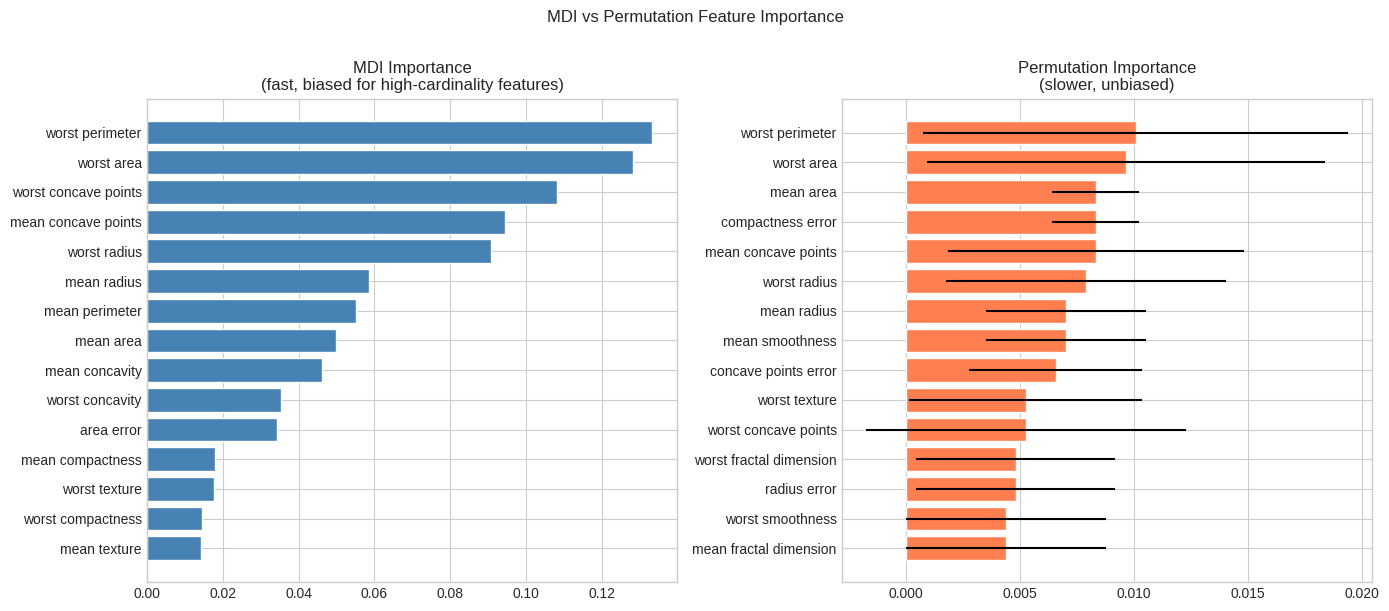

In [27]:
# Feature importances — MDI vs Permutation
from sklearn.inspection import permutation_importance

importances = rf.feature_importances_
feat_names  = data.feature_names
order_mdi   = np.argsort(importances)[-15:]

perm = permutation_importance(rf, X_te, y_te, n_repeats=20, random_state=42, n_jobs=-1)
order_perm = np.argsort(perm.importances_mean)[-15:]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh([feat_names[i] for i in order_mdi],
             importances[order_mdi], color='steelblue', edgecolor='white')
axes[0].set_title("MDI Importance\n(fast, biased for high-cardinality features)")

axes[1].barh([feat_names[i] for i in order_perm],
             perm.importances_mean[order_perm], color='coral', edgecolor='white',
             xerr=perm.importances_std[order_perm])
axes[1].set_title("Permutation Importance\n(slower, unbiased)")

plt.suptitle("MDI vs Permutation Feature Importance", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 6. Hyperparameter Tuning

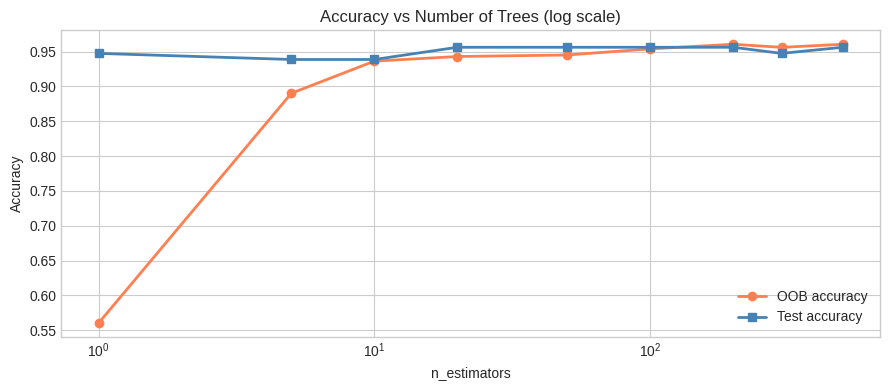

In [28]:
# n_estimators — when do more trees stop helping?
n_range = [1, 5, 10, 20, 50, 100, 200, 300, 500]
oob_accs, test_accs = [], []

for n in n_range:
    rf_n = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf_n.fit(X_tr, y_tr)
    oob_accs.append(rf_n.oob_score_)
    test_accs.append(rf_n.score(X_te, y_te))

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(n_range, oob_accs,  'o-', color='coral',     linewidth=2, label='OOB accuracy')
ax.semilogx(n_range, test_accs, 's-', color='steelblue', linewidth=2, label='Test accuracy')
ax.set_title("Accuracy vs Number of Trees (log scale)")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators':     randint(50, 500),
    'max_depth':        [None, 5, 10, 20],
    'max_features':     ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_leaf': randint(1, 10),
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)
search.fit(X_tr, y_tr)

print("Best parameters:", search.best_params_)
print(f"Best CV accuracy: {search.best_score_:.4f}")
print(f"Test  accuracy:   {search.best_estimator_.score(X_te, y_te):.4f}")


Best parameters: {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 3, 'n_estimators': 264}
Best CV accuracy: 0.9626
Test  accuracy:   0.9561


## 7. Common Mistakes

In [30]:
# MISTAKE 1: More trees cannot fix high bias
from sklearn.datasets import make_moons
X_moon, y_moon = make_moons(n_samples=300, noise=0.3, random_state=42)
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_moon, y_moon, test_size=0.3, random_state=0)

print("Shallow RF (max_depth=1) — high bias, more trees don't help:")
print(f"  {'n_estimators':<14}  {'Test acc':>10}")
for n in [1, 10, 100, 500]:
    m_ = RandomForestClassifier(n_estimators=n, max_depth=1, random_state=42)
    m_.fit(X_tr_m, y_tr_m)
    print(f"  {n:<14}  {m_.score(X_te_m, y_te_m):10.4f}")

print("\nDeep RF (max_depth=None) — bagging handles variance:")
for n in [1, 10, 100, 500]:
    m_ = RandomForestClassifier(n_estimators=n, max_depth=None, random_state=42)
    m_.fit(X_tr_m, y_tr_m)
    print(f"  {n:<14}  {m_.score(X_te_m, y_te_m):10.4f}")


Shallow RF (max_depth=1) — high bias, more trees don't help:
  n_estimators      Test acc
  1                   0.7778
  10                  0.8556
  100                 0.8333
  500                 0.8556

Deep RF (max_depth=None) — bagging handles variance:
  1                   0.8778
  10                  0.8556
  100                 0.8778
  500                 0.8778


In [31]:
# MISTAKE 2: Not using n_jobs=-1 on large data
import time

X_big, y_big = make_classification(n_samples=10000, n_features=20,
                                    n_informative=10, random_state=0)

t0 = time.time()
RandomForestClassifier(n_estimators=100, n_jobs=1,  random_state=0).fit(X_big, y_big)
t1 = time.time()
RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0).fit(X_big, y_big)
t2 = time.time()

print(f"n_jobs=1  (single core): {t1-t0:.2f}s")
print(f"n_jobs=-1 (all cores):   {t2-t1:.2f}s")
print(f"Speedup: {(t1-t0)/(t2-t1):.1f}x — always set n_jobs=-1 on large data.")


n_jobs=1  (single core): 6.11s
n_jobs=-1 (all cores):   4.22s
Speedup: 1.4x — always set n_jobs=-1 on large data.


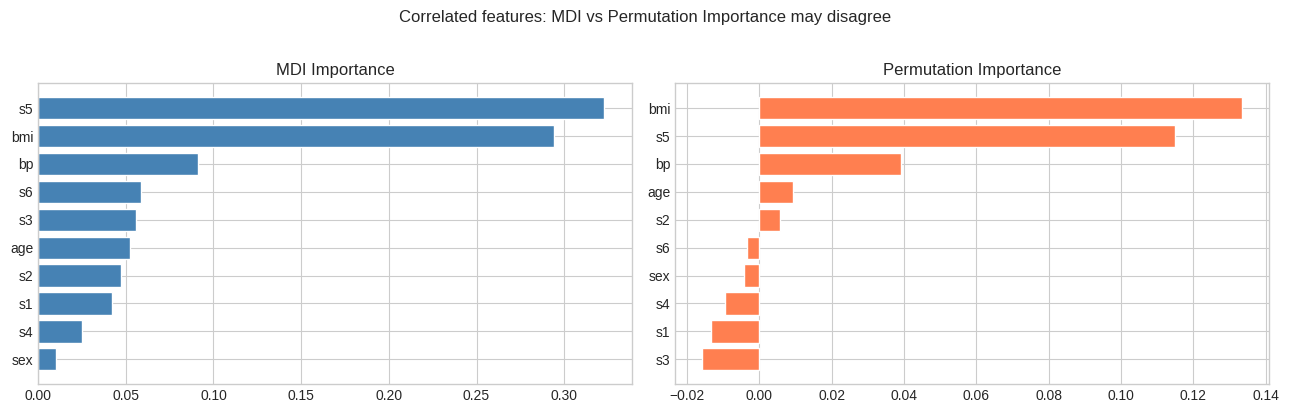

In [32]:
# MISTAKE 3: Trusting MDI importance with correlated features
# MDI splits importance arbitrarily between correlated features.
# Use permutation importance for reliable rankings.

from sklearn.datasets import load_diabetes
from sklearn.inspection import permutation_importance as perm_imp

data_d = load_diabetes()
X_d, y_d = data_d.data, data_d.target
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_d, y_d, test_size=0.2, random_state=0)

rf_d = RandomForestClassifier if False else __import__('sklearn.ensemble',
       fromlist=['RandomForestRegressor']).RandomForestRegressor
rf_d = rf_d(n_estimators=200, random_state=42, n_jobs=-1)
rf_d.fit(X_tr_d, y_tr_d)

mdi  = rf_d.feature_importances_
perm = perm_imp(rf_d, X_te_d, y_te_d, n_repeats=20, random_state=42).importances_mean
names = data_d.feature_names

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, imp, title, color in zip(axes, [mdi, perm],
        ['MDI Importance', 'Permutation Importance'], ['steelblue', 'coral']):
    order = np.argsort(imp)
    ax.barh([names[i] for i in order], imp[order], color=color, edgecolor='white')
    ax.set_title(title)

plt.suptitle("Correlated features: MDI vs Permutation Importance may disagree",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 8. Exercises

**Exercise 1:** Verify the 63.2% bootstrap coverage claim numerically. Simulate 5000 bootstrap samples for several values of $m$ and show the fraction of unique samples converges to $1 - e^{-1}$.


In [33]:
# Your code here


In [34]:
# Solution
rng_ex = np.random.default_rng(0)
print(f"Theoretical limit: 1 - e^(-1) = {1 - np.exp(-1):.6f}")

print(f"{'m':>6}  {'Avg unique fraction':>20}")
for m in [10, 50, 200, 1000, 5000]:
    fracs = [len(np.unique(rng_ex.choice(m, size=m, replace=True)))/m for _ in range(5000)]
    print(f"{m:>6}  {np.mean(fracs):>20.6f}")


Theoretical limit: 1 - e^(-1) = 0.632121
     m   Avg unique fraction
    10              0.654440
    50              0.637052
   200              0.633056
  1000              0.632397
  5000              0.632076


**Exercise 2:** Compare single tree, Bagging (no feature randomness), and Random Forest on the breast cancer dataset using 5-fold cross-validation. Explain why RF outperforms plain Bagging.


In [35]:
# Your code here


In [36]:
# Solution
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

models = {
    'Single Decision Tree':    DecisionTreeClassifier(random_state=42),
    'Bagging (max_features=1.0)': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100, max_features=1.0, random_state=42, n_jobs=-1),
    'Random Forest (sqrt)':    RandomForestClassifier(
        n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1),
}

data_bc = load_breast_cancer()
X_bc2, y_bc2 = data_bc.data, data_bc.target

print(f"{'Model':<32}  {'CV Accuracy':>12}  {'Std':>8}")
for name, model in models.items():
    s = cross_val_score(model, X_bc2, y_bc2, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"{name:<32}  {s.mean():12.4f}  {s.std():8.4f}")

print()
print("RF > Bagging because feature randomness decorrelates trees.")
print("Decorrelated trees -> lower ensemble variance -> better generalization.")


Model                              CV Accuracy       Std
Single Decision Tree                    0.9173    0.0242
Bagging (max_features=1.0)              0.9579    0.0382
Random Forest (sqrt)                    0.9561    0.0228

RF > Bagging because feature randomness decorrelates trees.
Decorrelated trees -> lower ensemble variance -> better generalization.


**Exercise 3:** Add `predict_proba` (soft voting) to `RandomForestScratch` and compare its calibration curve against hard voting.


In [37]:
# Your code here


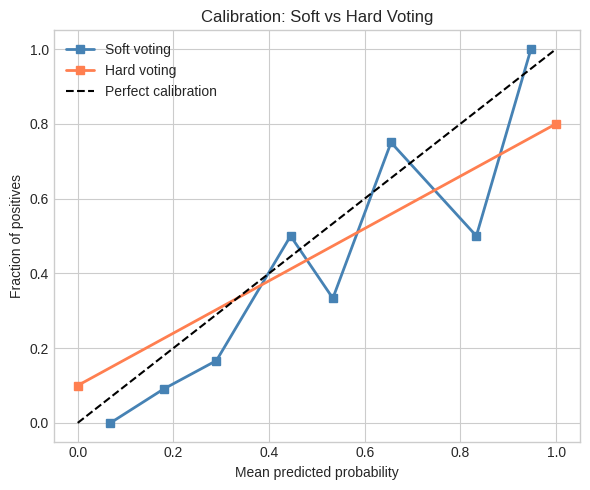

Soft voting gives smoother, better-calibrated probability estimates.


In [38]:
# Solution
from sklearn.calibration import calibration_curve

class RFScratchSoft(RandomForestScratch):
    def predict_proba(self, X):
        all_p = np.array([t.predict(X) for t in self.trees_])
        proba = np.zeros((X.shape[0], self.n_classes_))
        for k in range(self.n_classes_):
            proba[:,k] = (all_p == k).mean(axis=0)
        return proba

rf_soft = RFScratchSoft(n_estimators=50, max_depth=5, random_state=42)
rf_soft.fit(X_tr_rf, y_tr_rf)

p_soft = rf_soft.predict_proba(X_te_rf)[:,1]
p_hard = rf_soft.predict(X_te_rf).astype(float)

fig, ax = plt.subplots(figsize=(6, 5))
for p, label, color in [(p_soft,'Soft voting','steelblue'),(p_hard,'Hard voting','coral')]:
    pt, pp = calibration_curve(y_te_rf, p, n_bins=8)
    ax.plot(pp, pt, 's-', color=color, linewidth=2, label=label)
ax.plot([0,1],[0,1],'k--',linewidth=1.5,label='Perfect calibration')
ax.set_title("Calibration: Soft vs Hard Voting")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend()
plt.tight_layout()
plt.show()
print("Soft voting gives smoother, better-calibrated probability estimates.")


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
